<a href="https://colab.research.google.com/github/yigitavseren/DeepVision-Cifar10/blob/master/DeepVision_Cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

# 1. CIFAR-10 veri setini indiriyoruz
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# 2. Normalizasyon: Pikselleri 0-255 aralığından 0-1 aralığına çekiyoruz.
# Bu basit matematiksel dönüşüm, ağın çok daha verimli ve hızlı öğrenmesini sağlar.
x_train, x_test = x_train / 255.0, x_test / 255.0

print("Eğitim görsellerinin matris boyutu:", x_train.shape)
print("Eğitim etiketlerinin boyutu:", y_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Eğitim görsellerinin matris boyutu: (50000, 32, 32, 3)
Eğitim etiketlerinin boyutu: (50000, 1)


In [2]:
# Modeli ardışık katmanlar halinde inşa ediyoruz
model = tf.keras.models.Sequential([
    # 1. Evrişim Katmanı: Görüntüden özellikleri (kenar, çizgi) çıkarır
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    # Havuzlama Katmanı: Görüntü boyutunu küçültüp gereksiz detayları atar
    tf.keras.layers.MaxPooling2D((2, 2)),

    # 2. Evrişim Katmanı: Daha derin ve karmaşık özellikleri öğrenir
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # 3. Evrişim Katmanı
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

    # Düzleştirme Katmanı: 2 boyutlu matrisleri 1 boyutlu düz bir diziye çevirir
    tf.keras.layers.Flatten(),

    # Tam Bağlantılı Katman: Karar mekanizmasının beyni
    tf.keras.layers.Dense(64, activation='relu'),
    # Çıkış Katmanı: 10 farklı sınıfımız olduğu için 10 nöronla bitiriyoruz
    tf.keras.layers.Dense(10)
])

# Modeli derliyoruz (Öğrenme stratejisini belirliyoruz)
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Modelin genel özetini ve parametre sayısını ekrana basalım
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
history = model.fit(x_train, y_train, epochs=10,
                    validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - accuracy: 0.3444 - loss: 1.7649 - val_accuracy: 0.5590 - val_loss: 1.2283
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5689 - loss: 1.2060 - val_accuracy: 0.6156 - val_loss: 1.0977
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6351 - loss: 1.0324 - val_accuracy: 0.6548 - val_loss: 0.9893
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6773 - loss: 0.9263 - val_accuracy: 0.6696 - val_loss: 0.9519
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6963 - loss: 0.8622 - val_accuracy: 0.6876 - val_loss: 0.8998
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7197 - loss: 0.7979 - val_accuracy: 0.6835 - val_loss: 0.9346
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7364 - loss: 0.7490 - val_accuracy: 0.6937 - val_loss: 0.9017
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7580 - loss: 0.6937 -

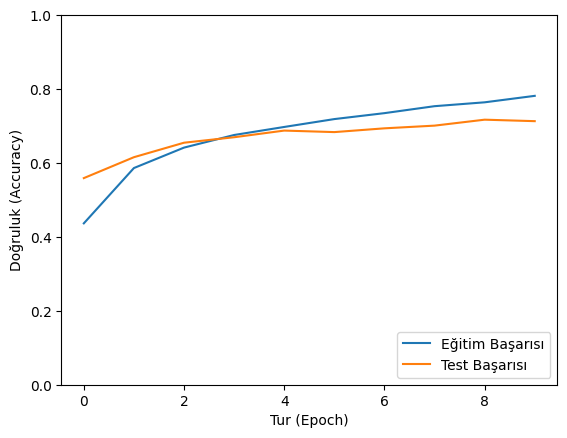

In [4]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Eğitim Başarısı')
plt.plot(history.history['val_accuracy'], label = 'Test Başarısı')
plt.xlabel('Tur (Epoch)')
plt.ylabel('Doğruluk (Accuracy)')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


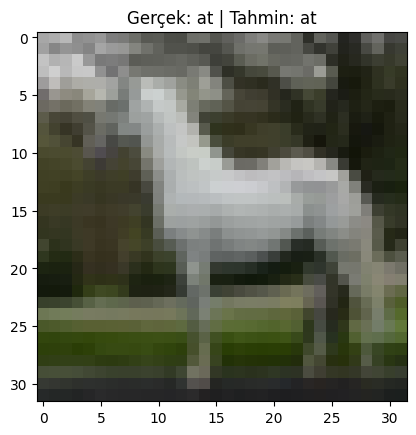

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# CIFAR-10 sınıf isimleri
sinif_isimleri = ['uçak', 'otomobil', 'kuş', 'kedi', 'geyik', 'köpek', 'kurbağa', 'at', 'gemi', 'kamyon']

# Test setinden 5. resmi alalım
resim_no = 5333
test_resmi = x_test[resim_no]
gercek_etiket = y_test[resim_no][0]

# Modelin tahmini (Model 10 tane olasılık verir, biz en yükseğini alırız)
tahminler = model.predict(np.expand_dims(test_resmi, axis=0))
tahmin_edilen_sinif = np.argmax(tahminler)

# Ekrana basalım
plt.imshow(test_resmi)
plt.title(f"Gerçek: {sinif_isimleri[gercek_etiket]} | Tahmin: {sinif_isimleri[tahmin_edilen_sinif]}")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


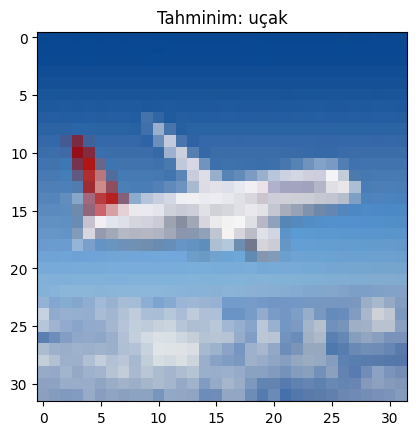

In [35]:
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image

# webp dosyanı yükle ve aç
img_path = 'thumbs_b_c_cce73c042b1f2f50b436d6e37dd44c34.jpg'
img = Image.open(img_path).convert('RGB') # Webp'yi RGB'ye çeviriyoruz
img = img.resize((32, 32)) # Modelin istediği 32x32 boyutuna getiriyoruz

img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

tahmin = model.predict(img_array)
sonuc = sinif_isimleri[np.argmax(tahmin)]

plt.imshow(img)
plt.title(f"Tahminim: {sonuc}")
plt.show()